<a href="https://colab.research.google.com/github/leebee33/codetree-TILs/blob/main/%EC%B4%88%EC%BD%94%ED%99%88%EB%9F%B0%EB%B3%BC_ML1_%EC%9D%B4%EC%9A%B0%EC%98%81.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import files
uploaded = files.upload()

Saving moldset_labeled_cn7.csv to moldset_labeled_cn7.csv
Saving moldset_labeled_rg3.csv to moldset_labeled_rg3.csv
Saving moldset_unlabeled_cn7.csv to moldset_unlabeled_cn7.csv
Saving moldset_unlabeled_rg3.csv to moldset_unlabeled_rg3.csv


In [54]:
!rm '/content/업로드 예제 파일.txt'

rm: cannot remove '/content/업로드 예제 파일.txt': No such file or directory


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
2. 전처리 #엔코딩 유형 찾기

In [21]:
import chardet
def detect_encoding(filepath):
  with open(filepath,'rb') as f:
       result = chardet.detect(f.read())
  return result['encoding']

filepath = "/content/moldset_labeled_cn7.csv"
filepath = "/content/moldset_labeled_rg3.csv" # Labeled dataset selected
# filepath = "/content/moldset_unlabeled_cn7.csv"
# filepath = "/content/moldset_unlabeled_rg3.csv"
encoding = detect_encoding(filepath)

print(f"Detected encoding: {encoding}")

Detected encoding: ascii


In [24]:
import pandas as pd
df = pd.read_csv(filepath, encoding=encoding, index_col=0)
print(df)

      PassOrFail  Injection_Time  Filling_Time  Plasticizing_Time  Cycle_Time  \
1211           0       -0.029099     -1.192531           1.977737    0.249511   
1212           0       -0.029099     -1.192531           1.977737    0.249511   
1213           0       -0.029099     -1.192531           1.528778    0.249511   
1214           0       -0.029099     -1.192531           1.528778    0.249511   
1215           0       -0.029099     -1.192531           0.630880   -0.298708   
...          ...             ...           ...                ...         ...   
2388           0       -0.029099      0.838552          -1.164915   -0.298708   
2389           0       -0.029099      0.838552          -1.613854   -0.846822   
2390           0       -0.029099      0.838552          -1.613854   -0.846822   
2391           0       -0.029099      0.838552          -0.491498   -1.395040   
2392           0       -0.029099      0.838552          -0.491498   -1.395040   

      Clamp_Close_Time  Cus

In [ ]:
#3.준비

In [ ]:
#3-1 변수과 타겟설정

In [13]:
columns = df.columns.tolist()

print(columns)

['Unnamed: 0', 'Injection_Time', 'Filling_Time', 'Plasticizing_Time', 'Cycle_Time', 'Clamp_Close_Time', 'Cushion_Position', 'Plasticizing_Position', 'Clamp_Open_Position', 'Max_Injection_Speed', 'Max_Screw_RPM', 'Average_Screw_RPM', 'Max_Injection_Pressure', 'Max_Switch_Over_Pressure', 'Max_Back_Pressure', 'Average_Back_Pressure', 'Barrel_Temperature_1', 'Barrel_Temperature_2', 'Barrel_Temperature_3', 'Barrel_Temperature_4', 'Barrel_Temperature_5', 'Barrel_Temperature_6', 'Hopper_Temperature', 'Mold_Temperature_3', 'Mold_Temperature_4']


In [25]:
features = ['Injection_Time', 'Filling_Time', 'Plasticizing_Time', 'Cycle_Time', 'Clamp_Close_Time', 'Cushion_Position', 'Plasticizing_Position', 'Clamp_Open_Position', 'Max_Injection_Speed', 'Max_Screw_RPM', 'Average_Screw_RPM', 'Max_Injection_Pressure', 'Max_Switch_Over_Pressure', 'Max_Back_Pressure', 'Average_Back_Pressure', 'Barrel_Temperature_1',
'Barrel_Temperature_2', 'Barrel_Temperature_3', 'Barrel_Temperature_4', 'Barrel_Temperature_5', 'Barrel_Temperature_6', 'Hopper_Temperature', 'Mold_Temperature_3', 'Mold_Temperature_4']

target = 'PassOrFail'

In [ ]:
#3-2 훈련 테스트 데이터 분할

In [26]:
from sklearn.model_selection import train_test_split
x=df[features]
y=df[target]
x_train,x_test,y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [ ]:
#4. 모델 생성

In [35]:
# 필요한 라이브러리 불러오기

from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

#모델 0: DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)

In [36]:
model.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [47]:
# 모델 1: DummyClassifier
# 가장 많은 클래스를 계속 예측하는 기준 모델
model1 = DummyClassifier(
    strategy="most_frequent"
)


In [49]:
model1.fit(x_train, y_train)

DummyClassifier(strategy='most_frequent')

In [40]:
# 모델 2: Logistic Regression
# 가장 단순한 분류 모델
# class_weight="balanced" → 클래스 불균형 보정
model2 = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)


In [50]:
model2.fit(x_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [44]:
# 모델 3: Random Forest
# 여러 개의 Decision Tree를 만들어 결과를 종합
# class_weight="balanced" → 클래스 불균형 보정
model3 = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [51]:
model3.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [ ]:
#6. 모델평가

In [45]:
from sklearn.metrics import accuracy_score

y_pred=model.predict(x_test)
accuracy=accuracy_score(y_test, y_pred)
print(f"Accuracy:{accuracy}")

Accuracy:0.9662447257383966


### 다른 모델 평가

In [52]:
from sklearn.metrics import accuracy_score

# DummyClassifier (model1) 평가
y_pred1 = model1.predict(x_test)
accuracy1 = accuracy_score(y_test, y_pred1)
print(f"DummyClassifier Accuracy: {accuracy1:.4f}")

# Logistic Regression (model2) 평가
y_pred2 = model2.predict(x_test)
accuracy2 = accuracy_score(y_test, y_pred2)
print(f"Logistic Regression Accuracy: {accuracy2:.4f}")

# Random Forest (model3) 평가
y_pred3 = model3.predict(x_test)
accuracy3 = accuracy_score(y_test, y_pred3)
print(f"Random Forest Accuracy: {accuracy3:.4f}")

DummyClassifier Accuracy: 0.9831
Logistic Regression Accuracy: 0.6118
Random Forest Accuracy: 0.9662


In [53]:
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve, auc, confusion_matrix

def evaluate_model(model_name, model_obj, x_test, y_test):
    print(f"\n--- {model_name} Evaluation ---")
    y_pred = model_obj.predict(x_test)

    # Calculate basic metrics
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"Recall: {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Calculate PR-AUC if model has predict_proba method
    if hasattr(model_obj, 'predict_proba'):
        y_probs = model_obj.predict_proba(x_test)[:, 1] # Probability of the positive class (1)
        precisions, recalls, _ = precision_recall_curve(y_test, y_probs)
        pr_auc = auc(recalls, precisions)
        print(f"PR-AUC: {pr_auc:.4f}")
    else:
        print("PR-AUC: Not applicable (model does not have predict_proba)")

    # Calculate False Negatives and False Positives
    cm = confusion_matrix(y_test, y_pred)
    # Assuming binary classification where 0 is negative and 1 is positive
    # cm = [[TN, FP],
    #       [FN, TP]]
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        print(f"False Negative (FN): {fn}")
        print(f"False Positive (FP): {fp}")
    else:
        print("False Negative (FN): Not applicable (confusion matrix shape)")
        print("False Positive (FP): Not applicable (confusion matrix shape)")

# Evaluate each model
evaluate_model("DecisionTreeClassifier (model)", model, x_test, y_test)
evaluate_model("DummyClassifier (model1)", model1, x_test, y_test)
evaluate_model("Logistic Regression (model2)", model2, x_test, y_test)
evaluate_model("Random Forest (model3)", model3, x_test, y_test)


--- DecisionTreeClassifier (model) Evaluation ---
Recall: 0.0000
Precision: 0.0000
F1 Score: 0.0000
PR-AUC: 0.0084
False Negative (FN): 4
False Positive (FP): 4

--- DummyClassifier (model1) Evaluation ---
Recall: 0.0000
Precision: 0.0000
F1 Score: 0.0000
PR-AUC: 0.5084
False Negative (FN): 4
False Positive (FP): 0

--- Logistic Regression (model2) Evaluation ---
Recall: 0.2500
Precision: 0.0111
F1 Score: 0.0213
PR-AUC: 0.0137
False Negative (FN): 3
False Positive (FP): 89

--- Random Forest (model3) Evaluation ---
Recall: 0.0000
Precision: 0.0000
F1 Score: 0.0000
PR-AUC: 0.0232
False Negative (FN): 4
False Positive (FP): 4


1. 의사결정트리: 정밀도 재현율이 0 인것으로 보아 모델이 양성 클래스를 제대로 예측하지 못함. 성능이 매우 저조.

2. dummyclassifier: 단순 규칙 빈도 기반 예측. FP는 0이지만 실제 양성을 모두 놓쳣음. 정밀도 재현율 0.

3. 로지스틱 회귀: 재현율 25%로 양성 클래스를 일부 감지. 하지만 FP가 89개로 너무 많아 음성 데이터를 잘못 예측한 경우가 많음. 이로 인해 정밀도가 0.111로 매우 낮아짐.

4. random forest:

In [30]:
print(y_pred)

[0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [31]:
#7. 예측

In [34]:
# 첫 번째 행 참고해서 간단한 랜덤데이터 생성
import numpy as np
import pandas as pd

first_row = df.iloc[0]

# 랜덤값 24개 생성
new_data = {}

for column in df.columns:

    value = first_row[column]

    # 숫자형 데이터
    if pd.api.types.is_numeric_dtype(df[column]):

        # 첫 번째 값의 ±10% 범위에서 랜덤 생성
        variation = abs(value) * 0.1

        # 값이 0인 경우
        if variation == 0:
            variation = 1
        new_data[column] = np.random.uniform(
            value - variation,
            value + variation,
            24
        )
# DataFrame으로 변환
new_df = pd.DataFrame(new_data)

# 결과 확인
print(new_df)

    PassOrFail  Injection_Time  Filling_Time  Plasticizing_Time  Cycle_Time  \
0    -0.841361       -0.029529     -1.224250           2.114758    0.239210   
1     0.920025       -0.031136     -1.179922           1.909886    0.258138   
2     0.428809       -0.028311     -1.131657           2.120502    0.227277   
3    -0.722733       -0.027515     -1.091286           2.105584    0.236326   
4     0.191567       -0.029158     -1.270644           1.889742    0.229174   
5     0.191826       -0.030970     -1.141783           2.037428    0.240033   
6     0.377321       -0.029361     -1.244276           1.789095    0.243981   
7    -0.737256       -0.029844     -1.173737           1.842634    0.235198   
8    -0.109183       -0.029864     -1.236150           2.049316    0.247654   
9     0.842663       -0.028516     -1.249588           1.805374    0.254419   
10   -0.849258       -0.031814     -1.243824           1.913860    0.227671   
11   -0.069330       -0.029640     -1.233551        

In [55]:
new_data = pd.DataFrame(new_data, columns=features)
prediction = model.predict(new_data)
print(f"Prediction for new data {prediction}")

Prediction for new data [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [56]:
#8. 시각화

<function matplotlib.pyplot.show(close=None, block=None)>

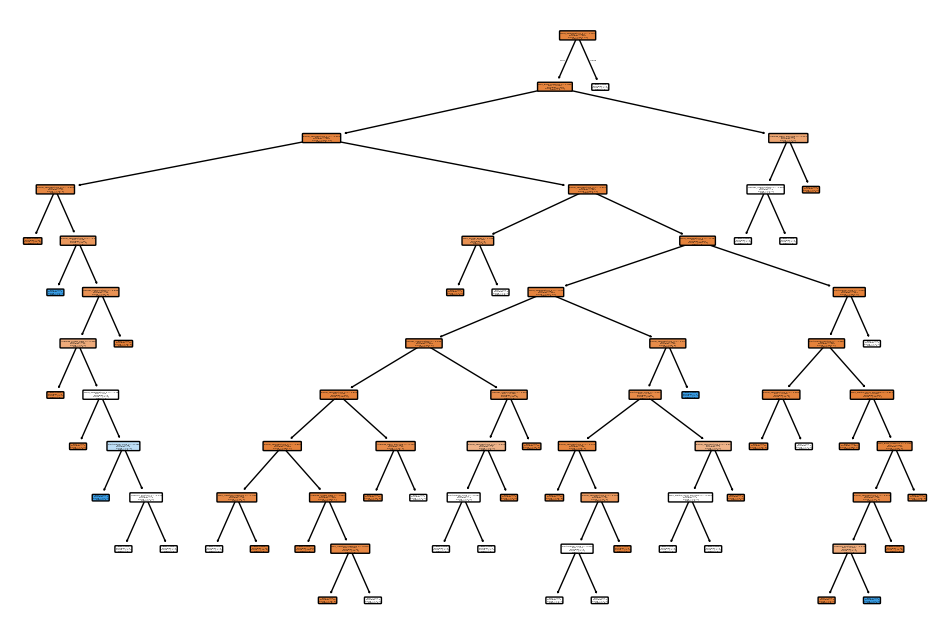

In [57]:
from sklearn import tree
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
tree.plot_tree(model, feature_names=features, class_names=['P', 'F'], filled=True, rounded=True)
plt.show

In [ ]:
#위의 텍스트들은 의사결정트리의 각 노드.

In [ ]:
#9.Pruning: 불필요한 부분제거. 중요도가 낮은 가중치나 뉴런제거.

In [59]:
model = DecisionTreeClassifier(random_state=42, ccp_alpha=0.0003)

In [ ]:
#9.2 최적 ccp_alpha값 확인(의사결정트리에서 과적합을 방지하는 하이퍼파라미터로
가지치기를 얼마나 할지 정하는 것)

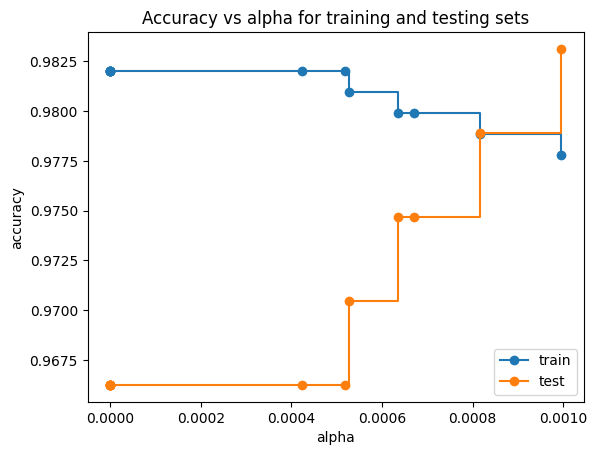

In [60]:
# 최적 ccp_alpha 값 확인
path = model.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

models = []
for ccp_alpha in ccp_alphas: #위의 여러 알파후보들로 각각 트리모델을 만듦.
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    model.fit(x_train, y_train) #학습시킴
    models.append(model)

train_scores = [model.score(x_train, y_train) for model in models]
test_scores = [model.score(x_test, y_test) for model in models]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker='o', label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker='o', label="test", drawstyle="steps-post")
ax.legend()
plt.show()

위의 그래프에서 정확도(y)가 가장 높게 뛰어오르는 alpha=3이 최적값이다.

In [ ]:
#10.저장

In [ ]:
import joblib
joblib.dump(model, 'decision_tree_model.pkl')

['decision_tree_model.pkl']